In [1]:
pip install dtw-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import os 
import matplotlib.pyplot as plt 
import numpy as np
import torch 
import pickle
import re
from numpy import genfromtxt
import torchaudio

In [3]:
# Cavity data located at: 
# C:\Users\449443\OneDrive - TMNA\ML1\wav2ecg_kleanthis_orig\results
nn_name_full = "[2025-01-14][08h34min24sec]"
dir_root     = os.path.join("C:\\","Users","449443","OneDrive - TMNA",
                            "ML1","wav2ecg_kleanthis_orig","results")
dir_file    = os.path.join(dir_root, "parveen_on_HRI_Test_09_conv-tasnet.npy")


In [4]:
#loading .npy file 
nn_results = np.load(dir_file)

from metrics import *
def evaluate_rec(data_name, test_file, model_name):
    path_true = f"results/{data_name}_on_{test_file}_{model_name}_true.npy"
    path_pred = f"results/{data_name}_on_{test_file}_{model_name}_pred.npy"
    assert os.path.exists(path_pred), "You must run predict.py first."
    
    y_true, y_pred = np.load(path_true), np.load(path_pred)
    mse = (y_true - y_pred) ** 2
    print(f"{data_name} tested on {test_file}:")
    print(f"MSE = {mse.mean():.4f} ± {mse.std():.4f}")

    return y_true, y_pred
sr = 2000
y_true, y_pred = evaluate_rec("parveen", "HRI_Test_08", "conv-tasnet")

AssertionError: You must run predict.py first.

In [ ]:
from metrics import *

sr = 2000
y_true, y_pred = evaluate_rec("all", "HRI_Test_08", "conv-tasnet")
y_true, y_pred = np.expand_dims(y_true, 0), np.expand_dims(y_pred, 0)

pos_true, pos_pred = r_peak_accuracy(y_true, y_pred, sr, error=0.005, return_pos=True)
rr_intervals(pos_true, pos_pred, sr)
heart_rate(pos_true, pos_pred, sr)

In [3]:
#loading the list containing names of all 4sec dataset files used for inference 
with open(dir_names, 'rb') as file:
    NAMES_INF = pickle.load(file)

print(NAMES_INF) 

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\449443\\OneDrive - TMNA\\wav2ecg_kleanthis_orig\\results\\parveen_on_HRI_Test_09_conv-tasnet.npy'

In [5]:
'''
All 100kmph data used in inference comes from the file [2024_10_02][4], shared by MIRISE.
Two moments of the dataset were used for 100kmph extraction.
Full NAMES_INF contains 4sec snippets data from these two different sources: 
1. a 100kmph drive that starts in time = 2831 sec and goes until time = 3515sec
    - files from this source have a tag "[2831-3515]" on filename
2. a 100kmph drive that starts in time = 3515 sec and goes until time = 3747sec
    - files from this source have a tag "[3515-3747]" on filename

There is a 50% overlap between two consecutive files
    
These two sources will be separated into individual lists
'''

list_2831 = [s for s in NAMES_INF if "[2831-3515]" in s]
list_3515  = [s for s in NAMES_INF if "[3515-3747]" in s]

#verifying the list is accurate:
print("list_2831: ")
for names in list_2831:
    print(names)

list_2831: 
[1,0005][2024_10_02][4][2831-3515][100kmph][B2]
[101][2024_10_02][4][2831-3515][100kmph][B2]
[103][2024_10_02][4][2831-3515][100kmph][B2]
[105][2024_10_02][4][2831-3515][100kmph][B2]
[107][2024_10_02][4][2831-3515][100kmph][B2]
[109][2024_10_02][4][2831-3515][100kmph][B2]
[11,001][2024_10_02][4][2831-3515][100kmph][B2]
[111][2024_10_02][4][2831-3515][100kmph][B2]
[113][2024_10_02][4][2831-3515][100kmph][B2]
[115][2024_10_02][4][2831-3515][100kmph][B2]
[117][2024_10_02][4][2831-3515][100kmph][B2]
[119][2024_10_02][4][2831-3515][100kmph][B2]
[121][2024_10_02][4][2831-3515][100kmph][B2]
[123][2024_10_02][4][2831-3515][100kmph][B2]
[125][2024_10_02][4][2831-3515][100kmph][B2]
[127][2024_10_02][4][2831-3515][100kmph][B2]
[129][2024_10_02][4][2831-3515][100kmph][B2]
[13,001][2024_10_02][4][2831-3515][100kmph][B2]
[131][2024_10_02][4][2831-3515][100kmph][B2]
[133][2024_10_02][4][2831-3515][100kmph][B2]
[135][2024_10_02][4][2831-3515][100kmph][B2]
[137][2024_10_02][4][2831-3515][10

In [7]:
def sort_by_bracket_number(string_list):
  """
  This function will rearrange the list elements chronologically. 
  In each list, the files are not ordered in chronological order. 
  However, each filname contains a timestamp in brackets. 

  Args:
    string_list: The list of strings to be sorted.

  Returns:
    A new list with the strings sorted by the number within the brackets.
  """

  def extract_number(string):
    """Extracts the number within brackets from a string."""
    #re.search(pattern, string): This is a function from the re module used for pattern matching in strings.
    #pattern: This is the regular expression that defines the pattern to search for.
    #string: This is the string where the search will be conducted.
    string = string.replace(",", "]")
    match = re.search(r"\[(\d{1,5})\]", string)
    return int(match.group(1)) if match else 0

  return sorted(string_list, key=extract_number)

In [8]:

sorted_2831 = sort_by_bracket_number(list_2831)
sorted_3515 = sort_by_bracket_number(list_3515)

In [9]:
#verifying accuracy of sorting process: 
for names in sorted_3515:
    print(names)

[1,0005][2024_10_02][4][3515-3747][100kmph][B2]
[3,0005][2024_10_02][4][3515-3747][100kmph][B2]
[5,0005][2024_10_02][4][3515-3747][100kmph][B2]
[7,0005][2024_10_02][4][3515-3747][100kmph][B2]
[9,0005][2024_10_02][4][3515-3747][100kmph][B2]
[11,001][2024_10_02][4][3515-3747][100kmph][B2]
[13,001][2024_10_02][4][3515-3747][100kmph][B2]
[15,001][2024_10_02][4][3515-3747][100kmph][B2]
[17][2024_10_02][4][3515-3747][100kmph][B2]
[19][2024_10_02][4][3515-3747][100kmph][B2]
[21][2024_10_02][4][3515-3747][100kmph][B2]
[23][2024_10_02][4][3515-3747][100kmph][B2]
[25][2024_10_02][4][3515-3747][100kmph][B2]
[27][2024_10_02][4][3515-3747][100kmph][B2]
[29][2024_10_02][4][3515-3747][100kmph][B2]
[31][2024_10_02][4][3515-3747][100kmph][B2]
[33,001][2024_10_02][4][3515-3747][100kmph][B2]
[35,001][2024_10_02][4][3515-3747][100kmph][B2]
[37,001][2024_10_02][4][3515-3747][100kmph][B2]
[39,001][2024_10_02][4][3515-3747][100kmph][B2]
[41,001][2024_10_02][4][3515-3747][100kmph][B2]
[43,001][2024_10_02][4][

In [10]:
sample_rate = int(2e3)
list = sorted_2831[0:30]
def get_continuous_data(list, extension):
    '''
    this method will load the data files based on their names from list element
    then the files will be concatenated and averaged, to generate one continuous file 
    that contains all elements from the list
    - list: this list contains filenames sorted chronologically, each file is 4 sec long data with 50% overlap with the consecutive file.  
    - extension: it's a string, either [PRED_ECG] or [REAL_ECG].
    '''
    
    array = np.zeros((2*len(list)+8)*sample_rate)

    lim_low = 0
    lim_up = int(lim_low + 4*sample_rate)
    for data_name in list: 
        path = os.path.join(dir_root, "csv", data_name + extension + nn_name_full+".csv")
        data = genfromtxt(path,delimiter=' ')
        array[lim_low:lim_up] = array[lim_low:lim_up] + data

        #updating indices
        lim_low = int(lim_low + 2*sample_rate)
        lim_up  = int(lim_low + 4*sample_rate)

    #normalizing the array: overlap doesn't happen in first 2sec of data, 
    #or in the last 2 sec. So before normalizing, these need to be corrected 
    array[0:2*sample_rate] = 2*array[0:2*sample_rate] 

    #removing trailing zeros at the end of the array
    array = array[0:(lim_up-4*sample_rate)]

    #normalizing
    array = array / np.max(np.abs(array))

    return array 

array_pred = get_continuous_data(list, "[PRED_ECG]")
array_real = get_continuous_data(list, "[REAL_ECG]")

In [11]:
len(array_pred)/sample_rate
continuous_pred_2831 = get_continuous_data(sorted_2831, "[PRED_ECG]")
continuous_real_2831 = get_continuous_data(sorted_2831, "[REAL_ECG]")

continuous_pred_3515 = get_continuous_data(sorted_3515, "[PRED_ECG]")
continuous_real_3515 = get_continuous_data(sorted_3515, "[REAL_ECG]")

print(f"2831 continuous data: {continuous_pred_2831.shape[0]/sample_rate} sec long")
print(f"3515 continuous data: {continuous_pred_3515.shape[0]/sample_rate} sec long")


2831 continuous data: 398.0 sec long
3515 continuous data: 146.0 sec long


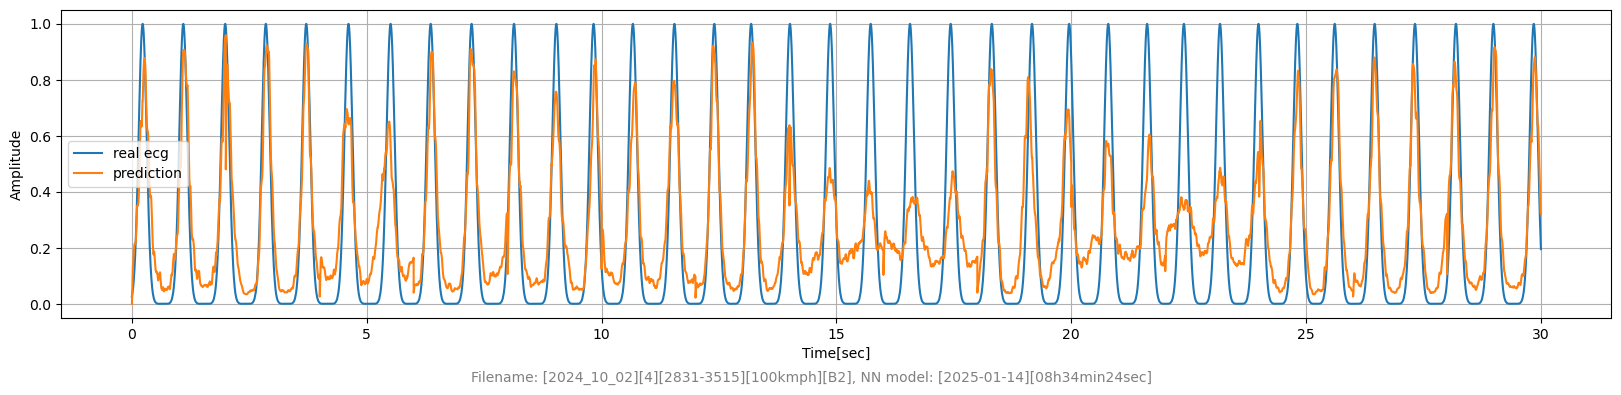

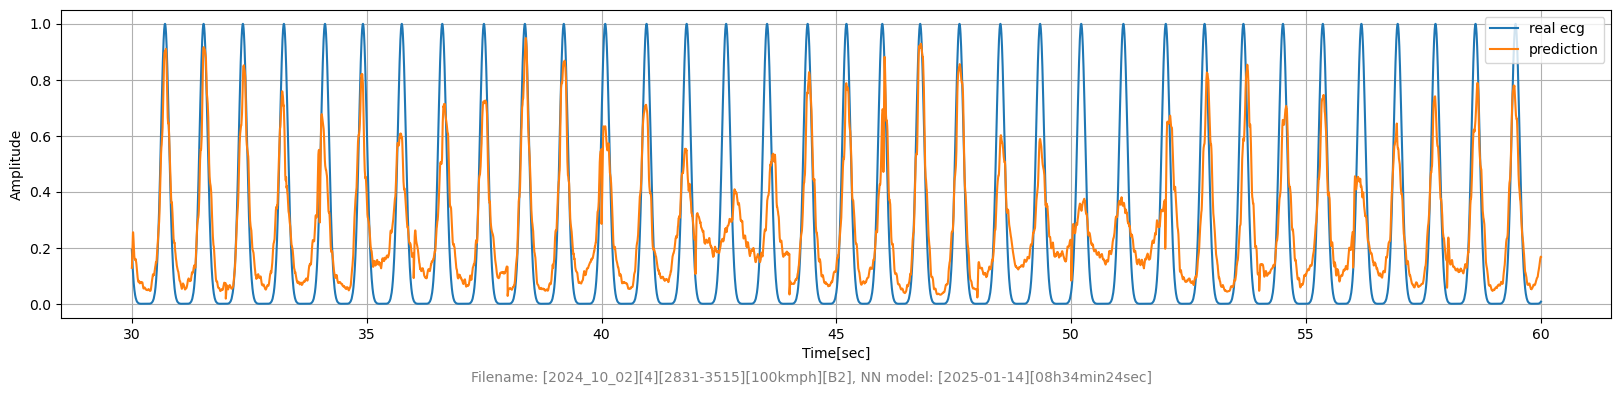

In [12]:
def plot_continuous_data(array_real, array_pred, duration, start_time):
    end_time = start_time + duration
    time_axis = np.arange(start_time, end_time, 1/sample_rate)

    plt.figure(figsize=(20,4))

    #plotting the normalized data 
    plt.plot(time_axis, array_real[int(start_time*sample_rate) : int(end_time*sample_rate)], label = 'real ecg')
    plt.plot(time_axis, array_pred[int(start_time*sample_rate) : int(end_time*sample_rate)], label = 'prediction')
    plt.xlabel('Time[sec]')
    plt.ylabel('Amplitude')
    if array_real.shape[0] > 790000:
        str_filename = "[2024_10_02][4][2831-3515][100kmph][B2]"
    else: 
        str_filename = "[2024_10_02][4][3515-3747][100kmph][B2]"
    plt.figtext(0.5, -0.05,f'Filename: {str_filename}, NN model: {nn_name_full}', ha='center', fontsize=10, color='gray')
    plt.legend()
    plt.grid(True)
    


#start = np.arange(0, 360, 30)
start = np.arange(0, 60, 30)
for p in start:
    plot_continuous_data(continuous_real_2831, continuous_pred_2831, duration=30, start_time=p)

In [13]:
peak_threshold = 0.4
from scipy.signal import find_peaks

def get_peaks(array):
    '''
    This function gets the peaks from the array
    - max hr in humans: 220 bpm minus age
    - for an 18 years old: 202bpm = 13.5 beats per 4 secs = 1beat per 296ms
    - at 2 kHz: 1 px = 0.5ms, so min distance = 296ms/.5ms = 592 px
    '''
    peaks, _ = find_peaks(array, height=peak_threshold, distance = 592)
    return peaks


def get_heartbeat_match(ecg, pred):
    ''' 
    Checks if the heartbeat peaks between ground truth and estiamtion 
    are matching.
    Parameters: 
    - ecg: array containig time location of all ground truth peaks
    - pred: array containig time location of all NN predicted peaks

    Output: 
    - matching_heartbeats: 
        - array of 2 rows and n columns, n being the number of beats in ecg
        - if entries are zero, it means there was no HR match
        - if entries are other number, it shows the match 
    '''
    hr_match = np.zeros(shape=(2, ecg.shape[0]))

    #looping over each element in ground truth,
    #except first and last elements bc of edge issues
    for i in np.arange(1,(ecg.shape[0]-1)):

        #establishing lower and upper boundaries around a heartbeat 
        gap_l = (ecg[i]- ecg[i-1])/2
        gap_r = (ecg[i+1] - ecg[i])/2
        
        #list to store all potential heartbeat candidates from prediction array
        candidates_list = []
        #looping over prediction array, to check if an element fits the gap 
        for j in np.arange(1,(pred.shape[0]-1)):
            if pred[j] > ecg[i]-gap_l and pred[j] < ecg[i]+gap_r:
                candidates_list.append(pred[j])
            
        #if there is one element in candidates_list, this is a correct HR match
        #if there is 0 elements, or >1 element, it means predition failed for that 
        #specific heartbeat
        if len(candidates_list) == 1:
            #print("correct estimation for ecg[i]")
            hr_match[0,i] = ecg[i]
            hr_match[1,i] = candidates_list[0]

    #getting indices of columns containing only zeros (where there was no match)
    zero_cols = np.where(~hr_match.any(axis=0))[0]
    #deleting columns containing only zeros 
    hr_match_final = np.delete(hr_match, zero_cols, axis=1)
    

    return hr_match_final

peaks_real_3515 = get_peaks(continuous_real_3515)
peaks_pred_3515 = get_peaks(continuous_pred_3515)

peaks_real_2831 = get_peaks(continuous_real_2831)
peaks_pred_2831 = get_peaks(continuous_pred_2831)

match_2831 = get_heartbeat_match(ecg=peaks_real_2831, pred=peaks_pred_2831)
match_3515 = get_heartbeat_match(ecg=peaks_real_3515, pred=peaks_pred_3515)



In [14]:

def get_global_analysis(hr_match, total_peaks):
    '''
    This method calculates %HR match and HRI MAE for the entire recording 
    - hr_match: array containing all the hr maatches between ground truth and NN prediction
    - total_peaks: total number of heartbeats present in ground truth 
        IMPORTANT: first and last ecgpeaks are not analized for hr_match,
        so total peaks is the size of ECG array minus 2
    '''

    global_hr_match = hr_match.shape[1]/total_peaks

    hr_hri = hr_match[0,1:] - hr_match[0,:-1]
    nn_hri = hr_match[1,1:] - hr_match[1,:-1]

    return global_hr_match, global_mae

num_real_peaks = peaks_real_3515.shape[0]-2
num_matches = match_3515.shape[1]
global_hr_match = num_matches/num_real_peaks


hr_hri = match_3515[0,1:] - match_3515[0,:-1]

nn_hri = match_3515[1,1:] - match_3515[1,:-1]

global_mae = np.mean(np.abs(nn_hri - hr_hri)) / sample_rate


print(num_real_peaks)
print(num_matches)
print(global_hr_match)
print(global_mae)

#test = get_global_analysis(match_2831, (peaks_real_2831.shape[0]-2))

173
161
0.930635838150289
0.03825625


In [15]:
test1, test2 = get_global_analysis(match_3515, (peaks_real_3515.shape[0]-2))
print(test1)
print(test2)

0.930635838150289
0.03825625


In [16]:
match_total = np.concatenate((match_2831, match_3515), axis=1)
peaks_real_total = (peaks_real_3515.shape[0]-2) + (peaks_real_2831.shape[0]-2)
global_hr_match_3, global_mae_3 = get_global_analysis(match_total, peaks_real_total)

print(f"NN vestion: {nn_name_full}")
print(f"global hr match: {round(global_hr_match_3*100,2)}%")
print(f"global HRI mae: {round(global_mae_3*1000,2)}ms")

NN vestion: [2025-01-14][08h34min24sec]
global hr match: 88.96%
global HRI mae: 38.26ms


# Inspecting Heart Rate in BPM

In [17]:
#total time in first recording is time between second heartbeat to second to last heartbeat (first and last heartbeats are never analyzed)
time_2831 = (peaks_pred_2831[-2] - peaks_pred_2831[1]) / sample_rate

#heart rate per second: num_beats / time_sec
#heart rate per minute: num_beats * 60 / time_sec 
hr_real_2831 = (peaks_real_2831.shape[0]-2)*60 / time_2831
hr_pred_2831 = (peaks_pred_2831.shape[0]-2)*60 / time_2831

print("Heart rate for 2831 recordings: ")
print(f"ground truth HR: {round(hr_real_2831,1)}bpm")
print(f"pred truth HR: {round(hr_pred_2831,1)}bpm")

Heart rate for 2831 recordings: 
ground truth HR: 71.6bpm
pred truth HR: 63.2bpm


In [18]:
#total time in first recording is time between second heartbeat to second to last heartbeat (first and last heartbeats are never analyzed)
time_3515 = (peaks_pred_3515[-2] - peaks_pred_3515[1]) / sample_rate

#heart rate per second: num_beats / time_sec
#heart rate per minute: num_beats * 60 / time_sec 
hr_real_3515 = (peaks_real_3515.shape[0]-2)*60 / time_3515
hr_pred_3515 = (peaks_pred_3515.shape[0]-2)*60 / time_3515

print("Heart rate for 3515 recordings: ")
print(f"ground truth HR: {round(hr_real_3515,1)}bpm")
print(f"pred truth HR: {round(hr_pred_3515,1)}bpm")

Heart rate for 3515 recordings: 
ground truth HR: 72.3bpm
pred truth HR: 68.1bpm


In [19]:
#global heart rate 
total_time = time_3515 + time_2831

hr_real_global = (peaks_real_3515.shape[0]-2 + peaks_real_2831.shape[0]-2)*60 / total_time
hr_pred_global = (peaks_pred_3515.shape[0]-2 + peaks_pred_2831.shape[0]-2)*60 / total_time

print(nn_name_full)
print("Global heart rate analysis (2831 + 3515): ")
print(f"ground truth HR: {round(hr_real_global,1)}bpm")
print("**********************")
print(f"PREDICTION HR: {round(hr_pred_global,1)}bpm")
print("**********************")

[2025-01-14][08h34min24sec]
Global heart rate analysis (2831 + 3515): 
ground truth HR: 71.8bpm
**********************
PREDICTION HR: 64.5bpm
**********************
